# Learning to Control an Energy Storage System in NeuroMANCER

This tutorial demonstrates the use of [Differentiable predictive control (DPC)](https://www.sciencedirect.com/science/article/pii/S0959152422000981) method to learn constrained neural policy for controlling [pumped-storage hydroelectricity](https://en.wikipedia.org/wiki/Pumped-storage_hydroelectricity) system described by [nonlinear ordinary differential equations (ODE)](https://en.wikipedia.org/wiki/Ordinary_differential_equation).


## Pumped-storage Hyrdoelectricity System

Lets consider a [pumped-storage hydroelectricity](https://en.wikipedia.org/wiki/Pumped-storage_hydroelectricity) (PSH) system which is a type of hydroelectric energy storage used by electric power systems for load balancing.
[Load balancing](https://en.wikipedia.org/wiki/Load_balancing_(electrical_power)) or daily peak demand reserve refers to the use of various techniques by electrical power stations to store excess electrical power during low demand periods for release as demand rises. These techniques are an important part of modern power system that help to balance the time-varying load with the generation.
As of 2020, the largest form of [grid energy storage]((https://en.wikipedia.org/wiki/Grid_energy_storage)) is dammed hydroelectricity, with both conventional hydroelectric generation as well as pumped-storage hydroelectricity.

<img src="https://github.com/pnnl/neuromancer/blob/master/examples/domain_examples/figs/PSH.PNG?raw=1" width="600">  

image adopted from: https://www.upsbatterycenter.com/blog/pumped-storage-hydroelectricity/


**System schematics**:  
<img src="https://github.com/pnnl/neuromancer/blob/master/examples/figs/two_tank_level.png?raw=1" width="250">  

**System model**:  
A simplified system dynamics of PSH system is defined by following nonlinear ordinary differential equations (ODEs):
$$
 \frac{dx_1}{dt} = c_1 (1.0 - v)  p - c_2  \sqrt{x_1}  \\  
 \frac{dx_2}{dt}  = c_1 v p + c_2  \sqrt{x_1} - c_2 \sqrt{x_2}
$$  
With system states $x_1$, and $x_2$ representing liquid levels in tank 1 and 2, respectively. Control actions are pump modulation $p$, and valve opening $v$. The ODE system is parametrized by inlet and outlet valve coefficients $c_1$ and $c_2$, respectively.

System model and image adopted from: https://apmonitor.com/do/index.php/Main/LevelControl



## Differentiable Predictive Control

[Differentiable predictive control (DPC)](https://www.sciencedirect.com/science/article/pii/S0959152422000981) is a model-based offline policy optimization algorithm for learning constrained control policies for dynamical systems.

**Control ojective**:   
The objective is to control the tank levels of the PSH system into desired reference values by modulating the pump and valve control actions.

**Schematics of the Differentiable Predictive Control method**:  
<img src="https://github.com/pnnl/neuromancer/blob/master/examples/control/figs/DPC_simple_method.png?raw=1" width="600">  

**Neural control policy**:  
The objective of this tutorial is to learn neural control policy $u_k = \pi(x_k, R)$ to control the tank levels by modulating the pump and valve control actions $u_k = [p_k, v_k]$. The policy takes in the measurements of system states $x_k$ at thime $k$, prediciton of desired references $R = [r_k, ..., r_{k+N}]$ over pre-defined horizon $N$.

**Differentiable system model**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In this example, we compactly represent the system model by ODE equations  $\text{ODESolve}(f(x^i_k, u^i_k))$  describing the governing dynamics of the controlled system.

**Differentiable predictive control problem formulation**:  
We learn the explicit neural control policy by solving the following parametric optimal control problem:
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m  \Big( \sum_{k=1}^{N-1} Q_x||x^i_k - r^i_k||_2^2  + Q_N||x^i_N - r^i_N||_2^2 \Big) \\
&\text{subject to}    && x^i_{k+1} =  \text{ODESolve}(f(x^i_k, u^i_k)) \\
&                     && u^i_k = \pi_{\theta}(x^i_k, R^i) \\
&                     && 0 \le x^i_k \le 1 \\
&                     && 0 \le u^i_k \le 1 \\
&                     && x^i_0 \sim \mathcal{P}_{x_0} \\
&                     && R^i \sim  \mathcal{P}_R
\end{align}
$$  
The objective function is to minimize the reference tracking error $||x^i_k - r^i_k||_2^2$ over pre-defined prediction horizon $N$ weighted by a scalar $Q_x$, including terminal penalty weighted by $Q_N$.  The parametric neural control policy is given by $\pi_{\theta}(x^i_k, R^i)$. The neural control policy is optimized over a problem parameters sampled from the distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, for state initial conditions, and references, respectively. The parameters $\theta$ are optimized with stochastic gradient descent.


### References
[1] [Ján Drgoňa, Karol Kiš, Aaron Tuor, Draguna Vrabie, Martin Klaučo,
Differentiable predictive control: Deep learning alternative to explicit model predictive control for unknown nonlinear systems,
Journal of Process Control, Volume 116, 2022](https://www.sciencedirect.com/science/article/pii/S0959152422000981)  
[2] [Jan Drgona, Aaron Tuor, Draguna Vrabie, Learning Constrained Adaptive Differentiable Predictive Control Policies With Guarantees, 2020, arXiv:2004.11184](https://arxiv.org/abs/2004.11184)  
[3] Example inspired by: https://apmonitor.com/do/index.php/Main/LevelControl


## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [1]:
!pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"

  Cloning https://github.com/pnnl/neuromancer.git (to revision master) to /tmp/pip-install-c3gxgcnf/neuromancer_eab98db46e0a44d7b798ea686014b23c
  Running command git clone --filter=blob:none --quiet https://github.com/pnnl/neuromancer.git /tmp/pip-install-c3gxgcnf/neuromancer_eab98db46e0a44d7b798ea686014b23c
  Resolved https://github.com/pnnl/neuromancer.git to commit e9456ffa090637266b18bfbc78b0c2d6d5f7bd28
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10

In [2]:
import torch
import torch.nn as nn
import numpy as np

import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

## PHS system model to be controlled

In [3]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0
umax = 1.
xmin = 0
xmax = 1.

## Training dataset generation

For a training dataset we randomly sample initial conditions of states and sequence of admissible reference trajectories over predefined prediction horizon from given distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, respectively.

In [4]:
nsteps = 50  # prediction horizon
n_samples = 2000    # number of sampled scenarios

#  sampled references for training the policy
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Training dataset
train_data = DictDataset({'x': torch.rand(n_samples, 1, nx),   # sampled initial conditions of states
                          'r': batched_ref}, name='train')

# sampled references for development set
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Development dataset
dev_data = DictDataset({'x': torch.rand(n_samples, 1, nx),    # sampled initial conditions of states
                        'r': batched_ref}, name='dev')

# torch dataloaders
batch_size = 200
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           collate_fn=train_data.collate_fn,
                                           shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size,
                                         collate_fn=dev_data.collate_fn,
                                         shuffle=False)

## Differentiable system model and control policy in Neuromancer

Here we construct a closed-loop system as differentiable computational graph by coinnecting the system dynamics model  $x_{k+1} = \text{ODESolve}(f(x_k, u_k))$ with neural control policy $u_k = \pi_{\theta}(x_k, R)$. Hence we obtain a trainable system architecture:
$x_{k+1} = \text{ODESolve}(f(x_k, \pi_{\theta}(x_k, R)))$.

In [5]:
# white-box ODE model with no-plant model mismatch
two_tank_ode = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank_ode.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank_ode.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# integrate continuous time ODE
integrator = integrators.RK4(two_tank_ode, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
model = Node(integrator, ['x', 'u'], ['x'], name='model')

# neural net control policy with hard control action bounds
net = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32, 32],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy = Node(net, ['x', 'r'], ['u'], name='policy')

# closed-loop system model
cl_system = System([policy, model], nsteps=nsteps)
# cl_system.show()

## Differentiable Predictive Control objectives and constraints

Here we take advantage of Neuromancer's high level symbolic language to define objective and constraint terms of our optimal control problem.

In [6]:
# variables
x = variable('x')
ref = variable("r")
# objectives
regulation_loss = 5. * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = 10.*(x > xmin)
state_upper_bound_penalty = 10.*(x < xmax)
terminal_lower_bound_penalty = 10.*(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = 10.*(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

## Differentiable optimal control problem

Here we put things together to construct a differentibale optimal control problem.

In [7]:
# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [cl_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
# problem.show()

## Solve the problem

We solve the problem using stochastic gradient descent over pre-defined training data of sampled parameters.

In [8]:
optimizer = torch.optim.AdamW(problem.parameters(), lr=0.002)
#  Neuromancer trainer
trainer = Trainer(
    problem,
    train_loader, dev_loader,
    optimizer=optimizer,
    epochs=100,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50,
)
# Train control policy
best_model = trainer.train()
# load best trained model
trainer.model.load_state_dict(best_model)


epoch: 0  train_loss: 4.095758438110352
epoch: 1  train_loss: 3.5511984825134277
epoch: 2  train_loss: 3.065915584564209
epoch: 3  train_loss: 2.4695262908935547
epoch: 4  train_loss: 1.7953426837921143
epoch: 5  train_loss: 1.31466805934906
epoch: 6  train_loss: 1.1871557235717773
epoch: 7  train_loss: 1.1080044507980347
epoch: 8  train_loss: 1.019747257232666
epoch: 9  train_loss: 0.9521102905273438
epoch: 10  train_loss: 0.8990424275398254
epoch: 11  train_loss: 0.85304194688797
epoch: 12  train_loss: 0.8102696537971497
epoch: 13  train_loss: 0.7675054669380188
epoch: 14  train_loss: 0.7239975929260254
epoch: 15  train_loss: 0.6809641122817993
epoch: 16  train_loss: 0.6432954668998718
epoch: 17  train_loss: 0.60792076587677
epoch: 18  train_loss: 0.576795220375061
epoch: 19  train_loss: 0.5490268468856812
epoch: 20  train_loss: 0.5254220962524414
epoch: 21  train_loss: 0.5046579241752625
epoch: 22  train_loss: 0.48635968565940857
epoch: 23  train_loss: 0.4693507254123688
epoch: 24  

<All keys matched successfully>

# Evaluate best model on a system rollout


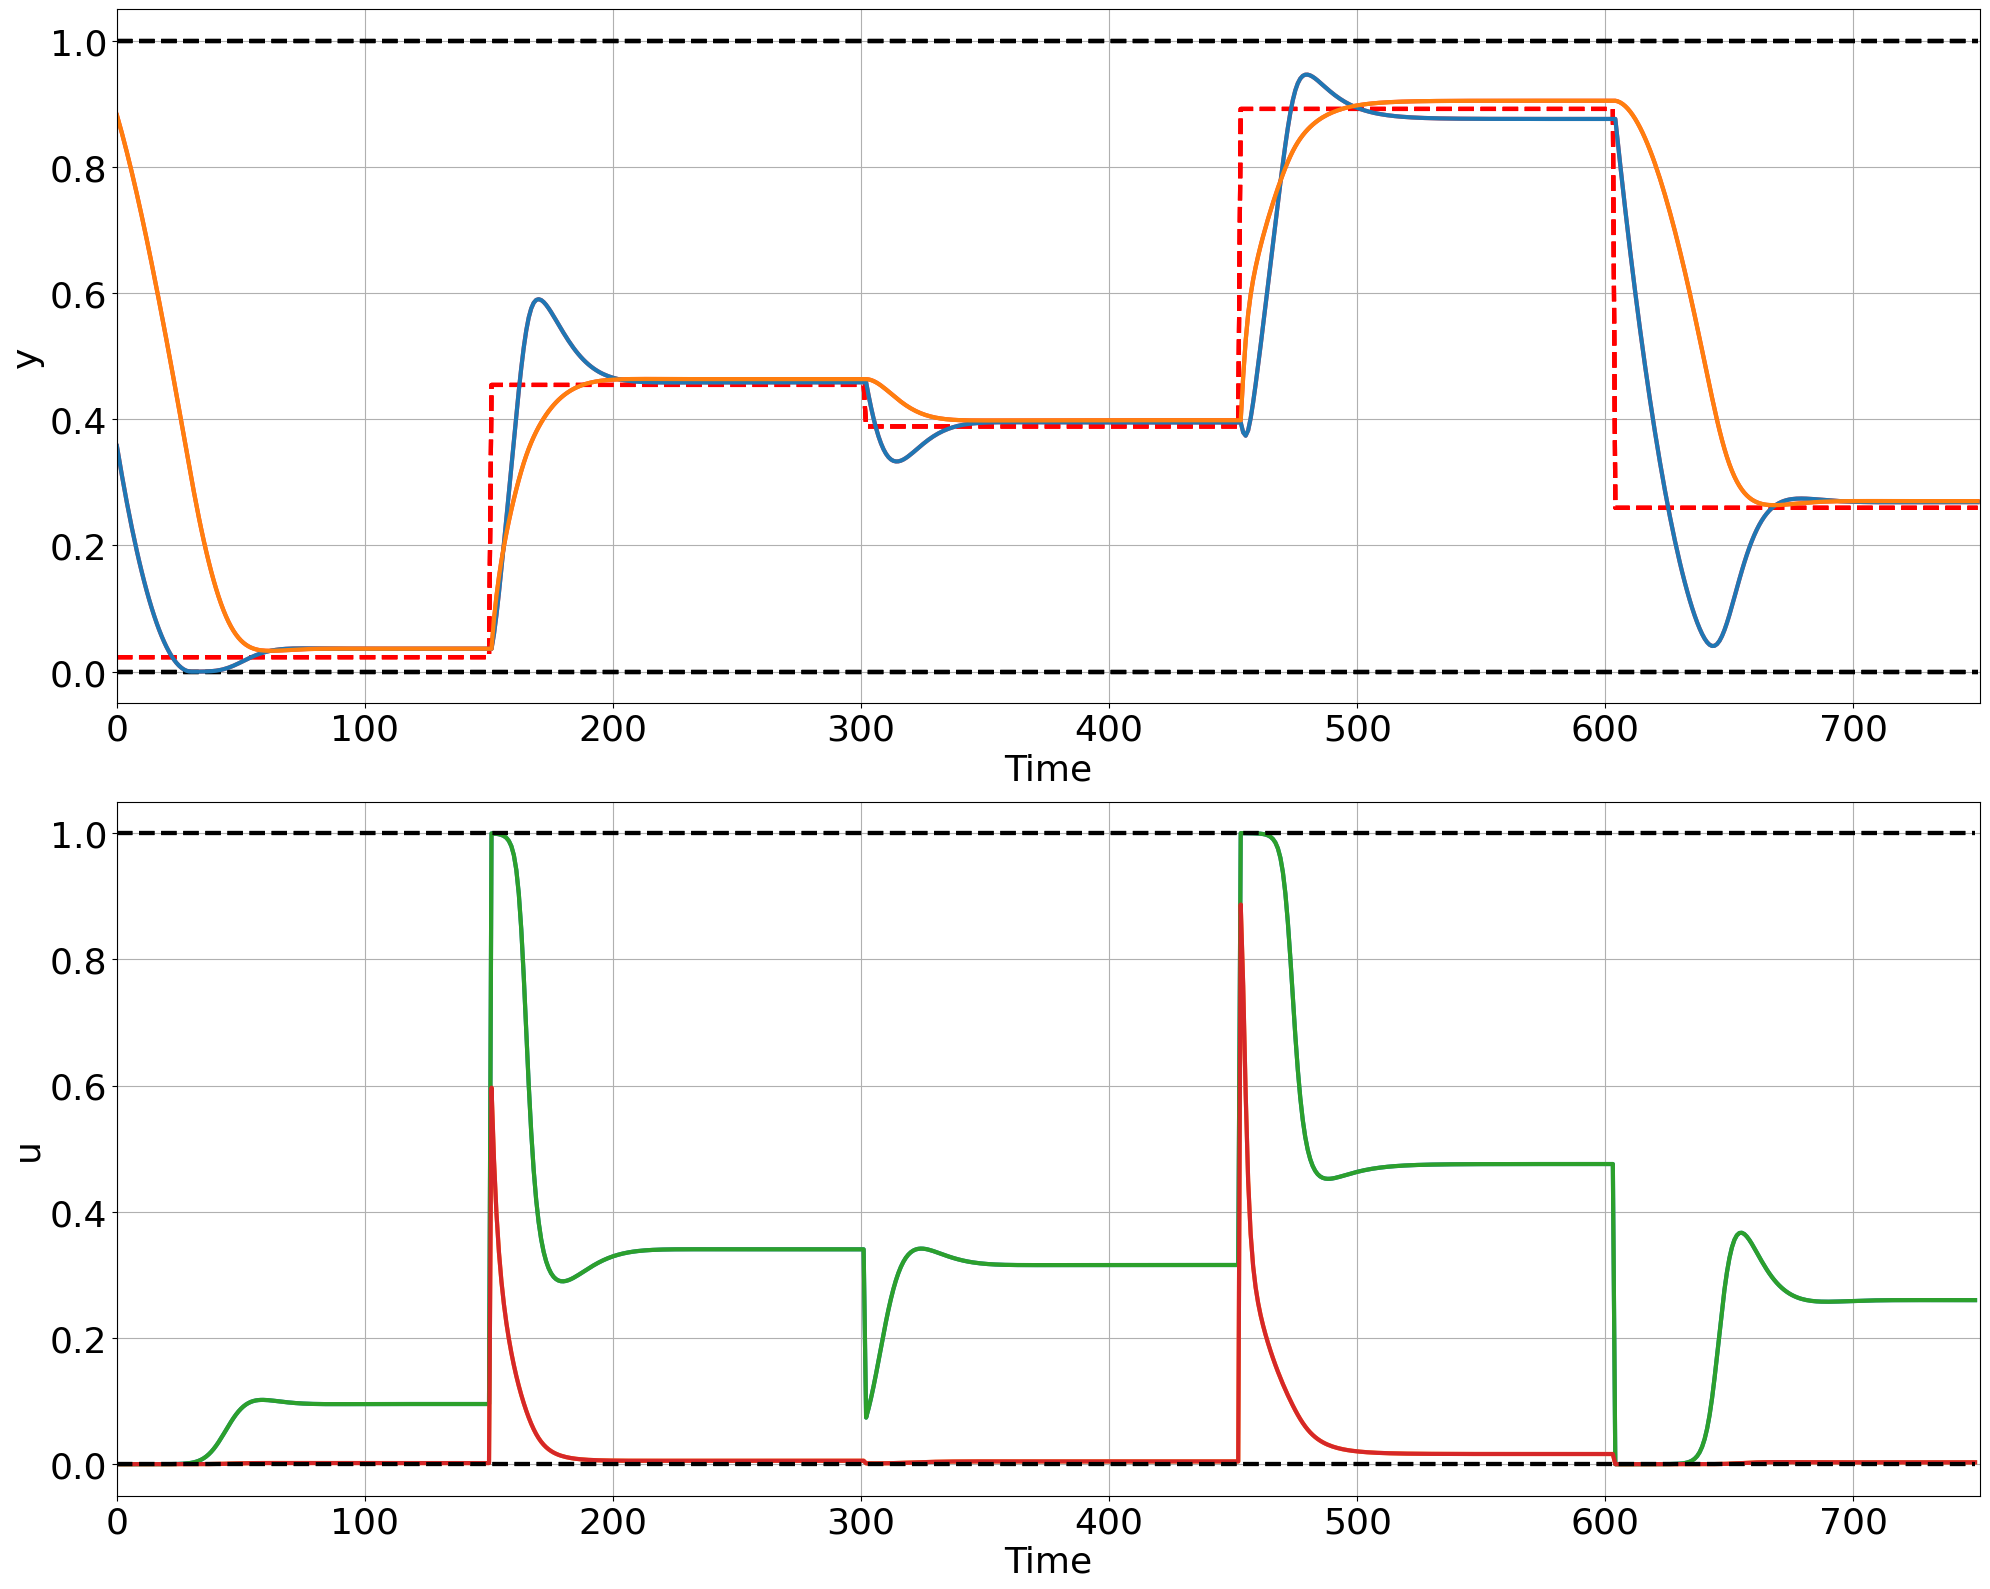

<Figure size 640x480 with 0 Axes>

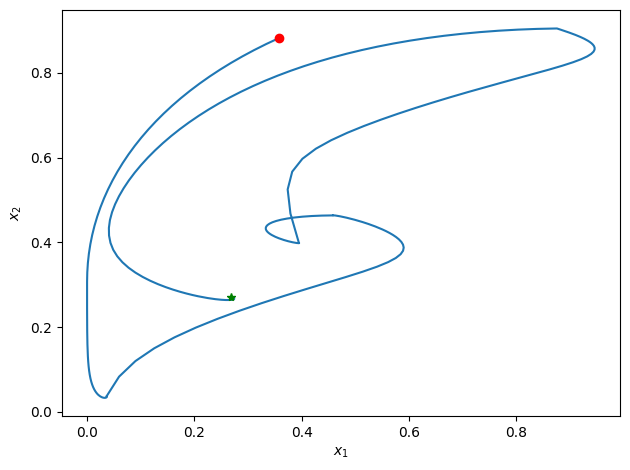

<Figure size 640x480 with 0 Axes>

In [10]:
nsteps = 750
step_length = 150
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=5)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
# generate initial data for closed loop simulation
data = {'x': torch.rand(1, 1, nx, dtype=torch.float32),
        'r': torch_ref}
cl_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')


In [12]:
import torch
import torch.nn as nn
from neuromancer.system import Node
from neuromancer.problem import Problem
from neuromancer.loss import PenaltyLoss, Objective, Constraint # Import Objective and Constraint
from neuromancer.constraint import variable
from neuromancer.trainer import Trainer
from neuromancer.dataset import DictDataset

# 1. Define the parameter to optimize
# We want to minimize (p - target_value)^2 subject to p >= lower_bound
# For example, target_value = 0.7, lower_bound = 0.5

class ParamToOptimize(nn.Module):
    def __init__(self, initial_val):
        super().__init__()
        # The parameter we want to optimize
        self.p = nn.Parameter(torch.tensor(initial_val, dtype=torch.float32))

    def forward(self, data=None):
        # Neuromancer Nodes expect dictionary outputs.
        # unsqueeze(0) adds a batch dimension (even if batch size is 1).
        # The key 'my_param' will be used to reference this variable in objectives/constraints.
        return {'my_param': self.p.unsqueeze(0)}

# --- Define problem parameters for this simple example ---
initial_param_value = 0.0  # Starting value for 'p' (e.g., below the lower_bound)
target_value = 0.7         # The value we want 'p' to be close to
lower_bound = 0.5          # 'p' must be greater than or equal to this value
constraint_weight = 100.0  # How strongly we penalize constraint violation

# Instantiate the module containing our optimizable parameter
param_module = ParamToOptimize(initial_param_value)

# Create a Neuromancer Node for this module.
# It takes no inputs (`[]`) and outputs the tensor associated with 'my_param'.
optimized_param_node = Node(param_module, [], ['my_param'], name='optimized_variable_node')

# 2. Define Objectives: Minimize the squared difference between 'my_param' and 'target_value'
my_param_var = variable('my_param') # This variable name must match the output key from the Node
# Define the symbolic expression for the objective
objective_expression = (my_param_var - target_value)**2
# Wrap the symbolic expression in a Neuromancer Objective object
objective = Objective(objective_expression, name='minimize_distance_to_target')
objectives = [objective]

# 3. Define Constraints: 'my_param' must be >= 'lower_bound'
# Neuromancer's constraint syntax: `weight * (condition_for_penalty)`
# We penalize when `my_param_var` is less than `lower_bound`.
# Define the symbolic expression for the constraint
constraint_expression = constraint_weight * (my_param_var < lower_bound)
# Wrap the symbolic expression in a Neuromancer Constraint object
constraint = Constraint(constraint_expression, name='param_lower_bound_constraint')
constraints = [constraint]

# 4. Construct the Differentiable Optimization Problem
# The 'components' list contains the computational graph elements. For this static case, just our node.
loss = PenaltyLoss(objectives=objectives, constraints=constraints)
problem = Problem(components=[optimized_param_node], loss=loss)

# 5. Create a Dummy DataLoader
# For static optimization, the Node's forward pass doesn't depend on input data.
# We just need a DataLoader to trigger the optimization loop for a few epochs.
dummy_data = DictDataset({'dummy_input': torch.tensor([0.])}, name='dummy')
train_loader = torch.utils.data.DataLoader(dummy_data, batch_size=1)
dev_loader = torch.utils.data.DataLoader(dummy_data, batch_size=1) # Using same for dev

# 6. Initialize Optimizer
# We pass the parameters of our `param_module` (i.e., 'p') to the optimizer.
optimizer = torch.optim.Adam(param_module.parameters(), lr=0.1)

# 7. Initialize and run the Trainer
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=100, # A reasonable number of epochs for convergence
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=0,
)

print(f"Initial parameter 'p' value: {param_module.p.item():.4f}")

# Train the problem
best_model_state = trainer.train()

# Load the best model state to retrieve the optimized parameter value
trainer.model.load_state_dict(best_model_state)

print(f"Optimized parameter 'p' value: {param_module.p.item():.4f}")

# Expected result:
# The optimized 'p' should converge to 0.7 because it minimizes the objective and satisfies the constraint.
# If `target_value` was below `lower_bound` (e.g., target_value=0.3, lower_bound=0.5),
# then 'p' would converge to `lower_bound` (0.5) because the constraint dominates the objective.

ImportError: cannot import name 'Objective' from 'neuromancer.loss' (/usr/local/lib/python3.12/dist-packages/neuromancer/loss.py)